# 05 · 방법 3 — 목표가 여럿일 때: 격자 · 조합 폭발 · 우선순위 · 변수 묶기

[![Colab에서 열기](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/keerhee/pension-fund-strategy-and-performance/blob/main/W06_LDI%EC%99%80GBI/W06_M8_%EC%8B%A4%EC%8A%B5_Colab/05_%EB%B0%A9%EB%B2%953_%EC%97%AC%EB%9F%AC%EB%AA%A9%ED%91%9C_%EC%A1%B0%ED%95%A9_%EC%9A%B0%EC%84%A0%EC%88%9C%EC%9C%84.ipynb)

**W06 M8 GBI 강의본 48 · 49장, 51~55장** 을 재현합니다.

| 단계 | 강의 | 이 노트북에서 |
|---|---|---|
| 조합 폭발 | 51장 | 목표 1 · 2 · 3 · 5개 → 100 · 10⁴ · 10⁶ · 10¹⁰ vs 이분법 20 · 40 · 60 · 100회 |
| 한 계좌 격자 | 47 · 48장 | 기준선 6 · 9 · 14억, (K, w) 21 × 41 = 861 후보 → 최소 7.1억 · w 60% (7.0억은 탈락) |
| 포함 사건 · 구간 분해 | 49장 | 98.7 + 86.9 + 48.5 = 234.1% → 구간 1.3 · 11.8 · 38.4 · 48.5% |
| 우선순위 순서 | 54 · 55장 | Safety 4.91 확정 → Market 이분법 10회 2.26 → Aspirational 51.8% → 합 9.14억 |
| 변수 묶기 | 52 · 53장 | ① Das–Markowitz 비중 6개 → γ 3개 ② CPPI는 m 하나 |

**실행 시간** — 기본 모드 10초 안팎(경로 100,000 × 10년, 후보 861개). `FAST = True`면 경로 20,000개.

### 0. 준비 — 이 셀부터 실행
한글 폰트(Colab은 나눔고딕 설치, 맥은 Pretendard), 강의 색(잉크 · 라임 · 티일 · 빨강), 강의본 숫자 확인 함수 `check()`를 준비합니다.
`check(이름, 계산값, 강의값, 허용오차)`는 계산이 강의본 숫자와 허용오차 안에서 맞는지 확인하고, 틀리면 멈춥니다(`assert`).
`FAST = True`로 바꾸면 경로 수를 줄여 빨리 돌고, 이때 확인은 표시만 합니다.

In [1]:
# ── 환경 준비: 한글 폰트 · 강의 색 · 확인 함수 (이 셀을 먼저 실행) ──
import sys, os, glob, math, time, subprocess
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import font_manager as fm

import warnings
warnings.filterwarnings("ignore", message=".*encountered in matmul")   # 맥 numpy(Accelerate)의 거짓 경고 — 결과와 무관
IN_COLAB = "google.colab" in sys.modules
if IN_COLAB and not glob.glob("/usr/share/fonts/truetype/nanum/NanumGothic*.ttf"):
    # Colab: 나눔 폰트 설치 (= !apt-get -qq install -y fonts-nanum) — 처음 한 번 10초 안팎
    subprocess.run("apt-get -qq install -y fonts-nanum > /dev/null", shell=True)

def setup_korean_font():
    """로컬 맥은 Pretendard, Colab은 나눔고딕을 matplotlib에 등록한다(폰트 캐시 갱신과 같은 효과)."""
    files = (glob.glob(os.path.expanduser("~/Library/Fonts/Pretendard-*.otf"))
             + glob.glob("/Library/Fonts/Pretendard-*.otf")
             + glob.glob("/usr/share/fonts/truetype/nanum/NanumGothic*.ttf"))
    for f in files:
        try:
            fm.fontManager.addfont(f)
        except Exception:
            pass
    names = {f.name for f in fm.fontManager.ttflist}
    for fam in ["Pretendard", "NanumGothic", "AppleGothic", "Malgun Gothic", "Noto Sans CJK KR"]:
        if fam in names:
            plt.rcParams["font.family"] = fam
            return fam
    return "(한글 폰트 없음 — 그래프 글자가 네모로 보이면 이 셀을 다시 실행)"

FONT = setup_korean_font()
plt.rcParams["axes.unicode_minus"] = False

# 강의 색 — 잉크 · 라임 · 티일 · 빨강 (+ 보조 회색 · 아이보리 바탕)
INK, LIME, TEAL, RED = "#071A1D", "#B7F34A", "#0B6B68", "#C00000"
GRAY, IVORY, OLIVE = "#8A9496", "#F7F5F0", "#5E8C1A"
plt.rcParams.update({
    "figure.figsize": (8, 4.5), "figure.dpi": 110, "savefig.dpi": 110,
    "figure.facecolor": "white", "axes.facecolor": IVORY,
    "axes.edgecolor": INK, "axes.labelcolor": INK, "xtick.color": INK, "ytick.color": INK,
    "axes.titleweight": "bold", "axes.titlesize": 13, "axes.titlelocation": "left",
    "axes.grid": True, "grid.color": "#DDD8CC", "grid.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False,
    "legend.frameon": False, "axes.axisbelow": True,
    "axes.prop_cycle": matplotlib.cycler(color=[TEAL, INK, RED, OLIVE, GRAY]),
})

# 빠른 모드 — True면 경로 · 표본 수를 줄여 빨리 끝난다(숫자가 강의와 소수 둘째 자리쯤 달라질 수 있어 확인은 표시만 한다)
FAST = False

CHECKS = []
def check(label, value, lecture, tol, fmt=".4f", unit=""):
    """계산값을 강의본 숫자와 비교한다. 기본(재현) 모드에서는 허용오차를 넘으면 멈춘다(assert)."""
    ok = abs(value - lecture) <= tol + 1e-9      # 허용오차는 보통 강의 표기 자릿수의 반(반올림하면 같은 값)
    CHECKS.append((label, ok))
    print(f"{'✓' if ok else '✗'} {label}: 계산 {value:{fmt}}{unit} · 강의 {lecture:{fmt}}{unit} (허용 ±{tol:g})")
    if not FAST:
        assert ok, f"{label}: 계산 {value} · 강의 {lecture}"

print(f"Colab: {IN_COLAB} · 그래프 폰트: {FONT} · numpy {np.__version__} · matplotlib {matplotlib.__version__}")

Colab: False · 그래프 폰트: Pretendard · numpy 2.0.2 · matplotlib 3.9.4


## 1. 목표가 여럿이면 조합이 폭발한다 (강의 51장)
목표마다 K 후보 10개 × 주식 비중 w 후보 10개 = 100개. 한 계좌로 묶어 모든 변수를 격자로 훑으면 목표 수만큼 곱해집니다.
계좌를 나누고 목표마다 이분법(약 20회)을 쓰면 20 × n회.

In [2]:
print(f"{'목표 수':>6s} {'한 계좌 격자 100ⁿ':>20s} {'후보당 0.01초면':>16s} {'계좌 분리 + 이분법':>18s}")
for n in (1, 2, 3, 5):
    cand = 100 ** n; sec = cand * 0.01
    tm = f"{sec / 3600:.1f}시간" if sec >= 3600 else f"{sec:.0f}초"
    if sec > 3600 * 24 * 365: tm = f"{sec / 3600 / 24 / 365:.0f}년"
    print(f"{n:>6d} {cand:>20,} {tm:>16s} {20 * n:>15d}회")
check("목표 3개: 100³ 후보를 0.01초씩 (시간)", 100**3 * 0.01 / 3600, 2.8, 0.05, ".2f")
check("목표 5개 후보 수 (log10)", math.log10(100**5), 10, 1e-9, ".0f")

  목표 수         한 계좌 격자 100ⁿ       후보당 0.01초면        계좌 분리 + 이분법
     1                  100               1초              20회
     2               10,000             100초              40회
     3            1,000,000            2.8시간              60회
     5       10,000,000,000               3년             100회
✓ 목표 3개: 100³ 후보를 0.01초씩 (시간): 계산 2.78 · 강의 2.80 (허용 ±0.05)
✓ 목표 5개 후보 수 (log10): 계산 10 · 강의 10 (허용 ±1e-09)


## 2. 경로 만들기 — 04 노트북과 같은 가정 · 같은 난수
GHP 2.02%/년, 주식 연 로그수익 r + λ − ½σ² + σε(λ 6%, σ 20%), seed 2026, 경로 100,000 × 10년, 매년 비중 되돌림.

In [3]:
SEED, T = 2026, 10
N = 20_000 if FAST else 100_000
r, lam, sig = 0.02, 0.06, 0.20
RG = math.exp(r) - 1
eps = np.random.default_rng(SEED).standard_normal((N, T))
R = np.exp(r + lam - 0.5 * sig * sig + sig * eps) - 1

def growth(w):
    """경로마다 10년 성장 배수 — 해마다 주식 w · GHP 1 − w로 되돌린다"""
    g = np.ones(N)
    for t in range(T):
        g *= w * (1 + R[:, t]) + (1 - w) * (1 + RG)
    return g
print(f"경로 {N:,} × {T}년 준비")

경로 100,000 × 10년 준비


## 3. 한 계좌 격자 — 후보 (K, w)마다 세 기준선에 닿을 확률 (강의 47 · 48장)
- K = 이 계좌에 오늘 넣는 총자본, w = 주식 비중(나머지 GHP, 레버리지 없음), 남는 자금 = 10 − K
- 기준선 6 · 9 · 14억 = 목표 6 · 3 · 5억을 우선순위대로 쌓은 누적(Safety 6 → +Market 3 = 9 → +Aspirational 5 = 14)
- 조건: P(W ≥ 6) ≥ 95%, P(W ≥ 9) ≥ 70%, P(W ≥ 14) ≥ 30%. **모든 후보에 같은 경로를 씁니다.**

In [4]:
LINES, TARGET = np.array([6.0, 9.0, 14.0]), np.array([0.95, 0.70, 0.30])
def probs(K, g):
    W = K * g
    return np.array([np.mean(W >= L) for L in LINES])

LECT_ROWS = [(7.5, 0.2, 100.0, 83.9, 1.2, False), (8.5, 0.2, 100.0, 97.8, 8.5, False), (7.5, 0.4, 99.4, 80.7, 20.4, False),
             (8.5, 0.4, 99.9, 91.5, 36.1, True), (7.5, 0.6, 96.9, 78.5, 36.0, True), (8.5, 0.6, 98.7, 86.9, 48.5, True)]
gcache = {}
print(f"{'후보':>16s} {'≥6억(95%)':>10s} {'≥9억(70%)':>10s} {'≥14억(30%)':>11s} {'남는 자금':>8s}  판정")
for K, w, s_, m_, a_, ok_ in LECT_ROWS:
    g = gcache.setdefault(w, growth(w)); p = probs(K, g); ok = bool(np.all(p >= TARGET))
    miss = [nm for nm, pi, ti in zip(["Safety", "Market", "Aspirational"], p, TARGET) if pi < ti]
    print(f"K {K}억 · w {w:.0%} {p[0]:10.1%} {p[1]:10.1%} {p[2]:11.1%} {10 - K:7.1f}억  {'통과' if ok else '탈락 — ' + ', '.join(miss)}")
    for nm, val, lect in zip(["≥6억", "≥9억", "≥14억"], p, (s_, m_, a_)):
        check(f"K {K} · w {w:.0%} {nm} (%)", 100 * val, lect, 0.051, ".2f")   # 표는 소수 첫째 자리 반올림(1.25 → 1.2)
    assert ok == ok_, "통과/탈락 판정이 강의 표와 다르다"

              후보   ≥6억(95%)   ≥9억(70%)   ≥14억(30%)    남는 자금  판정
K 7.5억 · w 20%     100.0%      83.9%        1.2%     2.5억  탈락 — Aspirational
✓ K 7.5 · w 20% ≥6억 (%): 계산 100.00 · 강의 100.00 (허용 ±0.051)
✓ K 7.5 · w 20% ≥9억 (%): 계산 83.90 · 강의 83.90 (허용 ±0.051)
✓ K 7.5 · w 20% ≥14억 (%): 계산 1.25 · 강의 1.20 (허용 ±0.051)
K 8.5억 · w 20%     100.0%      97.8%        8.5%     1.5억  탈락 — Aspirational
✓ K 8.5 · w 20% ≥6억 (%): 계산 100.00 · 강의 100.00 (허용 ±0.051)
✓ K 8.5 · w 20% ≥9억 (%): 계산 97.79 · 강의 97.80 (허용 ±0.051)
✓ K 8.5 · w 20% ≥14억 (%): 계산 8.53 · 강의 8.50 (허용 ±0.051)
K 7.5억 · w 40%      99.4%      80.7%       20.4%     2.5억  탈락 — Aspirational
✓ K 7.5 · w 40% ≥6억 (%): 계산 99.42 · 강의 99.40 (허용 ±0.051)
✓ K 7.5 · w 40% ≥9억 (%): 계산 80.71 · 강의 80.70 (허용 ±0.051)
✓ K 7.5 · w 40% ≥14억 (%): 계산 20.37 · 강의 20.40 (허용 ±0.051)
K 8.5억 · w 40%      99.9%      91.5%       36.1%     1.5억  통과
✓ K 8.5 · w 40% ≥6억 (%): 계산 99.90 · 강의 99.90 (허용 ±0.051)
✓ K 8.5 · w 40% ≥9억 (%): 계산 91.54 · 강의 91.50 (허용 ±0.051)
✓ K 8.5 · w 4

**전 격자 861개** — 주식 비중 0~100%(5%p) 21개 × 총자본 6~10억(0.1억) 41개. 비중마다 경로의 성장 배수를 한 번만 계산하고(공통 난수),
K는 곱하기만 하면 되므로 빠릅니다. 조건을 모두 만족하는 후보 중 K가 가장 작은 것을 고릅니다.

In [5]:
t0 = time.time()
WS = np.round(np.arange(0.0, 1.0001, 0.05), 2)
KS = np.round(np.arange(6.0, 10.001, 0.1), 2)
Pgrid = np.zeros((len(WS), len(KS), 3))
for i, w in enumerate(WS):
    g = gcache.setdefault(float(w), growth(float(w)))
    gs = np.sort(g)
    for j, K in enumerate(KS):
        Pgrid[i, j] = [1 - np.searchsorted(gs, L / K, side="left") / N for L in LINES]   # = mean(K·g ≥ L)
PASS = np.all(Pgrid >= TARGET, axis=2)
best = None
for i, w in enumerate(WS):
    js = np.where(PASS[i])[0]
    if len(js) and (best is None or KS[js[0]] < best[1]):
        best = (w, KS[js[0]], Pgrid[i, js[0]])
print(f"후보 {PASS.size}개 · 통과 {PASS.sum()}개 · {time.time() - t0:.2f}초")
w_b, K_b, p_b = best
i6 = list(WS).index(0.6)
p70 = Pgrid[i6, list(KS).index(7.0)]
print(f"최소 통과 K = {K_b}억 · w = {w_b:.0%} → {p_b[0]:.1%} · {p_b[1]:.1%} · {p_b[2]:.1%} · 남는 자금 {10 - K_b:.1f}억")
print(f"경계 K = 7.0억 · w = 60% → {p70[0]:.1%} · {p70[1]:.1%} · {p70[2]:.1%} → 탈락(Aspirational)")
check("격자 후보 수", PASS.size, 861, 0.5, ".0f")
check("최소 통과 K (억)", K_b, 7.1, 1e-9, ".1f"); check("최소 통과 w (%)", 100 * w_b, 60, 1e-9, ".0f")
for nm, val, lect in zip(["Safety", "Market", "Aspirational"], p_b, (95.8, 74.1, 30.9)):
    check(f"최소 K 7.1 {nm} (%)", 100 * val, lect, 0.05, ".1f")
for nm, val, lect in zip(["Safety", "Market", "Aspirational"], p70, (95.4, 72.8, 29.5)):
    check(f"경계 K 7.0 {nm} (%)", 100 * val, lect, 0.05, ".1f")

후보 861개 · 통과 320개 · 0.08초
최소 통과 K = 7.1억 · w = 60% → 95.8% · 74.1% · 30.9% · 남는 자금 2.9억
경계 K = 7.0억 · w = 60% → 95.4% · 72.8% · 29.5% → 탈락(Aspirational)
✓ 격자 후보 수: 계산 861 · 강의 861 (허용 ±0.5)
✓ 최소 통과 K (억): 계산 7.1 · 강의 7.1 (허용 ±1e-09)
✓ 최소 통과 w (%): 계산 60 · 강의 60 (허용 ±1e-09)
✓ 최소 K 7.1 Safety (%): 계산 95.8 · 강의 95.8 (허용 ±0.05)
✓ 최소 K 7.1 Market (%): 계산 74.1 · 강의 74.1 (허용 ±0.05)
✓ 최소 K 7.1 Aspirational (%): 계산 30.9 · 강의 30.9 (허용 ±0.05)
✓ 경계 K 7.0 Safety (%): 계산 95.4 · 강의 95.4 (허용 ±0.05)
✓ 경계 K 7.0 Market (%): 계산 72.8 · 강의 72.8 (허용 ±0.05)
✓ 경계 K 7.0 Aspirational (%): 계산 29.5 · 강의 29.5 (허용 ±0.05)


**그래프 — 격자 히트맵.** 칸의 색 = 세 조건 중 가장 모자란(또는 가장 여유가 적은) 것의 차이(센 확률 − 기준, %p).
티일 = 통과, 빨강 = 탈락, 굵은 선 = 통과 영역의 경계. 별 = 최소 통과 후보(7.1억 · 60%).

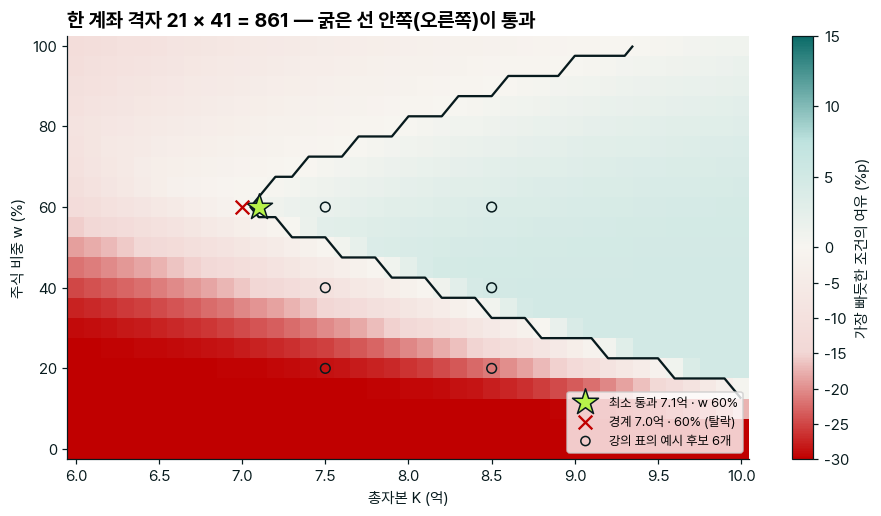

In [6]:
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm
margin = (Pgrid - TARGET).min(axis=2) * 100
cmap = LinearSegmentedColormap.from_list("gbi", [RED, "#F2D7D5", IVORY, "#BFE3DF", TEAL])
fig, ax = plt.subplots(figsize=(10, 5))
im = ax.pcolormesh(KS, WS * 100, margin, cmap=cmap, norm=TwoSlopeNorm(0, vmin=-30, vmax=15), shading="nearest")
ax.contour(KS, WS * 100, PASS.astype(float), levels=[0.5], colors=INK, linewidths=1.5)
ax.scatter(K_b, w_b * 100, marker="*", s=320, color=LIME, edgecolor=INK, zorder=5, label=f"최소 통과 {K_b}억 · w {w_b:.0%}")
ax.scatter(7.0, 60, marker="x", s=80, color=RED, zorder=5, label="경계 7.0억 · 60% (탈락)")
for K, w, *_ in LECT_ROWS:
    ax.scatter(K, w * 100, marker="o", s=40, facecolor="none", edgecolor=INK, zorder=4)
ax.scatter([], [], marker="o", facecolor="none", edgecolor=INK, label="강의 표의 예시 후보 6개")
cb = fig.colorbar(im, ax=ax); cb.set_label("가장 빠듯한 조건의 여유 (%p)")
ax.set_xlabel("총자본 K (억)"); ax.set_ylabel("주식 비중 w (%)")
ax.set_title("한 계좌 격자 21 × 41 = 861 — 굵은 선 안쪽(오른쪽)이 통과"); ax.legend(loc="lower right", fontsize=8.5, frameon=True, facecolor="white")
plt.show()

## 4. 격자 표의 %를 더하면 100%를 넘는다 — 그래도 정상 (강의 49장)
같은 행(K = 8.5억 · w = 60%)의 98.7 · 86.9 · 48.5%를 더하면 234.1%. 세 칸이 **서로 포함되는 사건**(≥ 6억 ⊃ ≥ 9억 ⊃ ≥ 14억)이기 때문입니다.
겹치지 않는 구간으로 나누면 한 경로는 한 칸에만 들어가고 합이 100%가 됩니다.

In [7]:
g6 = gcache[0.6]; W85 = 8.5 * g6
cum = probs(8.5, g6)
bins = [np.mean(W85 < 6), np.mean((W85 >= 6) & (W85 < 9)), np.mean((W85 >= 9) & (W85 < 14)), np.mean(W85 >= 14)]
print(f"누적(≥ 기준선) {cum[0]:.1%} + {cum[1]:.1%} + {cum[2]:.1%} = {cum.sum():.1%}  ← 합은 의미 없음")
print("구간 확률: " + " · ".join(f"{nm} {b:.1%}" for nm, b in zip(["6억 미만", "6~9억", "9~14억", "14억 이상"], bins)) + f" → 합 {sum(bins):.1%}")
check("누적 세 칸의 합 (%)", 100 * cum.sum(), 234.1, 0.05, ".1f")
for nm, b, lect in zip(["6억 미만", "6~9억", "9~14억", "14억 이상"], bins, (1.3, 11.8, 38.4, 48.5)):
    check(f"구간 {nm} (%)", 100 * b, lect, 0.05, ".1f")
check("구간 합 (%)", 100 * sum(bins), 100, 1e-9, ".1f")

누적(≥ 기준선) 98.7% + 86.9% + 48.5% = 234.1%  ← 합은 의미 없음
구간 확률: 6억 미만 1.3% · 6~9억 11.8% · 9~14억 38.4% · 14억 이상 48.5% → 합 100.0%
✓ 누적 세 칸의 합 (%): 계산 234.1 · 강의 234.1 (허용 ±0.05)
✓ 구간 6억 미만 (%): 계산 1.3 · 강의 1.3 (허용 ±0.05)
✓ 구간 6~9억 (%): 계산 11.8 · 강의 11.8 (허용 ±0.05)
✓ 구간 9~14억 (%): 계산 38.4 · 강의 38.4 (허용 ±0.05)
✓ 구간 14억 이상 (%): 계산 48.5 · 강의 48.5 (허용 ±0.05)
✓ 구간 합 (%): 계산 100.0 · 강의 100.0 (허용 ±1e-09)


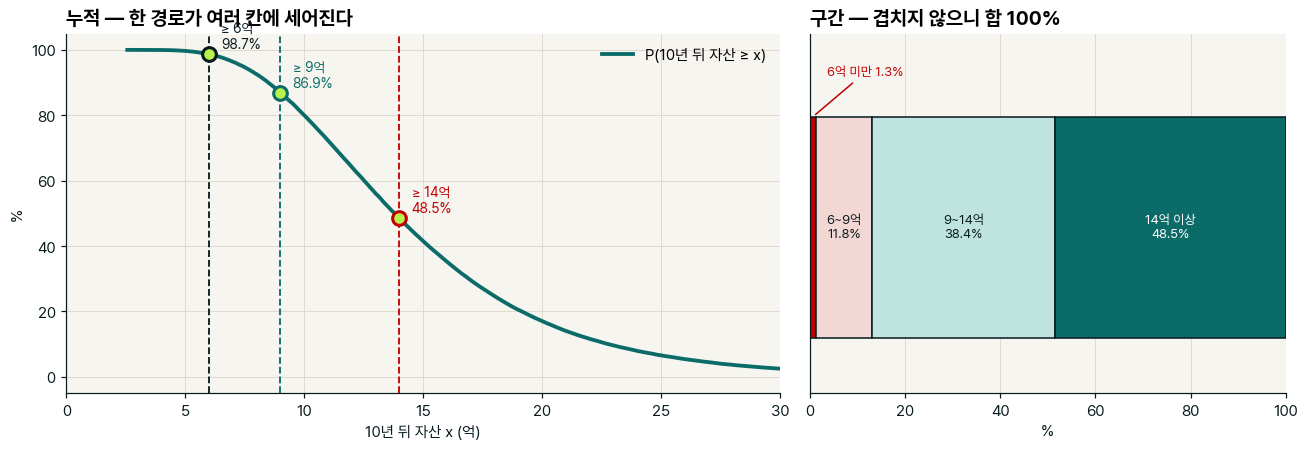

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.2), gridspec_kw={"width_ratios": [1.5, 1]})
xs = np.sort(W85); surv = 1 - np.arange(len(xs)) / len(xs)
ax1.plot(xs, surv * 100, color=TEAL, lw=2.5, label="P(10년 뒤 자산 ≥ x)")
for L, p_, c in zip(LINES, cum, [INK, TEAL, RED]):
    ax1.axvline(L, color=c, ls="--", lw=1.2)
    ax1.scatter(L, p_ * 100, s=80, color=LIME, edgecolor=c, zorder=5, lw=2)
    ax1.annotate(f"≥ {L:.0f}억\n{p_:.1%}", (L, p_ * 100), xytext=(8, 4), textcoords="offset points", fontsize=9, color=c)
ax1.set_xlim(0, 30); ax1.set_xlabel("10년 뒤 자산 x (억)"); ax1.set_ylabel("%")
ax1.set_title("누적 — 한 경로가 여러 칸에 세어진다"); ax1.legend(loc="upper right")
cols = [RED, "#F2D7D5", "#BFE3DF", TEAL]
left = 0
for nm, b, c in zip(["6억 미만", "6~9억", "9~14억", "14억 이상"], bins, cols):
    ax2.barh(0, b * 100, left=left, color=c, edgecolor=INK)
    if b < 0.05:   # 좁은 칸은 막대 위에 적는다
        ax2.annotate(f"{nm} {b:.1%}", (left + b * 50, 0.4), xytext=(left + b * 50 + 3, 0.55), fontsize=8.5, color=RED,
                     arrowprops=dict(arrowstyle="-", color=RED))
    else:
        ax2.text(left + b * 50, 0, f"{nm}\n{b:.1%}", ha="center", va="center", fontsize=8.5, color=INK if c != TEAL else "white")
    left += b * 100
ax2.set_xlim(0, 100); ax2.set_ylim(-0.6, 0.7); ax2.set_yticks([]); ax2.set_xlabel("%")
ax2.set_title("구간 — 겹치지 않으니 합 100%")
fig.tight_layout(); plt.show()

## 5. 우선순위 순서로 풀면 탐색 10번 — 대신 Safety는 확정 (강의 54 · 55장)
① Safety 6억 · 95%: GHP로 확정 — K = 6 × e^(−0.2) = 4.91억, 탐색 0회 → 남은 자금 5.09억
② Market 3억 · 70%: 남은 자금 [0, 5.09] 안에서 이분법 10번(폭이 0.005억 아래로)
③ Aspirational 5억 · 30%: 남은 자금의 달성 확률과 필요한 몫

In [9]:
def bisect(G, p, g, lo, hi, n_iter, log=None):
    """성공 비율(K × g ≥ G) ≥ p인 가장 작은 K — 구간을 반씩 좁힌다"""
    for i in range(n_iter):
        mid = (lo + hi) / 2
        pr = float(np.mean(mid * g >= G))
        if log is not None: log.append((i + 1, mid, pr, lo, hi))
        if pr >= p: hi = mid
        else: lo = mid
    return hi

t0 = time.time()
K_S = 6.0 * math.exp(-0.02 * T); left = 10.0 - K_S
gM = growth(0.6708)
log = []
K_M = bisect(3.0, 0.70, gM, 0.0, left, 10, log)
left2 = left - K_M
gA = growth(1.0)
pA_left = float(np.mean(left2 * gA >= 5.0))
K_A = bisect(5.0, 0.30, gA, 0.0, 50.0, 60)
sec = time.time() - t0
print(f"1단계 Safety: K = {K_S:.2f}억 (탐색 0회) → 남은 자금 {left:.2f}억")
for i, k, pr, lo, hi in log:
    print(f"2단계 Market 시도 {i:2d}: K = {k:.3f}억 → {pr:.2%} {'≥ 70% → 위를 줄인다' if pr >= 0.70 else '< 70% → 아래를 올린다'}")
print(f"   → Market K = {K_M:.2f}억 · 남은 자금 {left2:.2f}억")
print(f"3단계 Aspirational: 남은 {left2:.2f}억이면 달성 {pA_left:.1%} · 필요 K {K_A:.2f}억 → 여유 {left2 - K_A:.2f}억")
print(f"합계 {K_S:.2f} + {K_M:.2f} + {K_A:.2f} = {K_S + K_M + K_A:.2f}억 · {sec:.3f}초")
LECT_TRIALS = {1: (2.544, 79.02), 2: (1.272, 20.92), 3: (1.908, 55.23), 4: (2.226, 68.85), 8: (2.246, 69.56), 10: (2.261, 70.09)}
for i, k, pr, *_ in log:
    if i in LECT_TRIALS:
        check(f"Market 시도 {i} K", k, LECT_TRIALS[i][0], 0.0005, ".3f")
        check(f"Market 시도 {i} 비율 (%)", 100 * pr, LECT_TRIALS[i][1], 0.005, ".2f")
check("Safety K", K_S, 4.91, 0.005, ".2f"); check("남은 자금", left, 5.09, 0.005, ".2f")
check("Market K", K_M, 2.26, 0.005, ".2f"); check("Market 후 남은 자금", left2, 2.83, 0.005, ".2f")
check("남은 자금의 Aspirational 확률 (%)", 100 * pA_left, 51.8, 0.05, ".1f")
check("Aspirational 필요 K", K_A, 1.97, 0.005, ".2f"); check("여유", left2 - K_A, 0.86, 0.005, ".2f")
check("우선순위 합계 (억)", K_S + K_M + K_A, 9.14, 0.005, ".2f")

1단계 Safety: K = 4.91억 (탐색 0회) → 남은 자금 5.09억
2단계 Market 시도  1: K = 2.544억 → 79.02% ≥ 70% → 위를 줄인다
2단계 Market 시도  2: K = 1.272억 → 20.92% < 70% → 아래를 올린다
2단계 Market 시도  3: K = 1.908억 → 55.23% < 70% → 아래를 올린다
2단계 Market 시도  4: K = 2.226억 → 68.85% < 70% → 아래를 올린다
2단계 Market 시도  5: K = 2.385억 → 74.36% ≥ 70% → 위를 줄인다
2단계 Market 시도  6: K = 2.305억 → 71.72% ≥ 70% → 위를 줄인다
2단계 Market 시도  7: K = 2.266억 → 70.28% ≥ 70% → 위를 줄인다
2단계 Market 시도  8: K = 2.246억 → 69.56% < 70% → 아래를 올린다
2단계 Market 시도  9: K = 2.256억 → 69.92% < 70% → 아래를 올린다
2단계 Market 시도 10: K = 2.261억 → 70.09% ≥ 70% → 위를 줄인다
   → Market K = 2.26억 · 남은 자금 2.83억
3단계 Aspirational: 남은 2.83억이면 달성 51.8% · 필요 K 1.97억 → 여유 0.86억
합계 4.91 + 2.26 + 1.97 = 9.14억 · 0.009초
✓ Market 시도 1 K: 계산 2.544 · 강의 2.544 (허용 ±0.0005)
✓ Market 시도 1 비율 (%): 계산 79.02 · 강의 79.02 (허용 ±0.005)
✓ Market 시도 2 K: 계산 1.272 · 강의 1.272 (허용 ±0.0005)
✓ Market 시도 2 비율 (%): 계산 20.92 · 강의 20.92 (허용 ±0.005)
✓ Market 시도 3 K: 계산 1.908 · 강의 1.908 (허용 ±0.0005)
✓ Market 시도 3 비율 (%): 계산 5

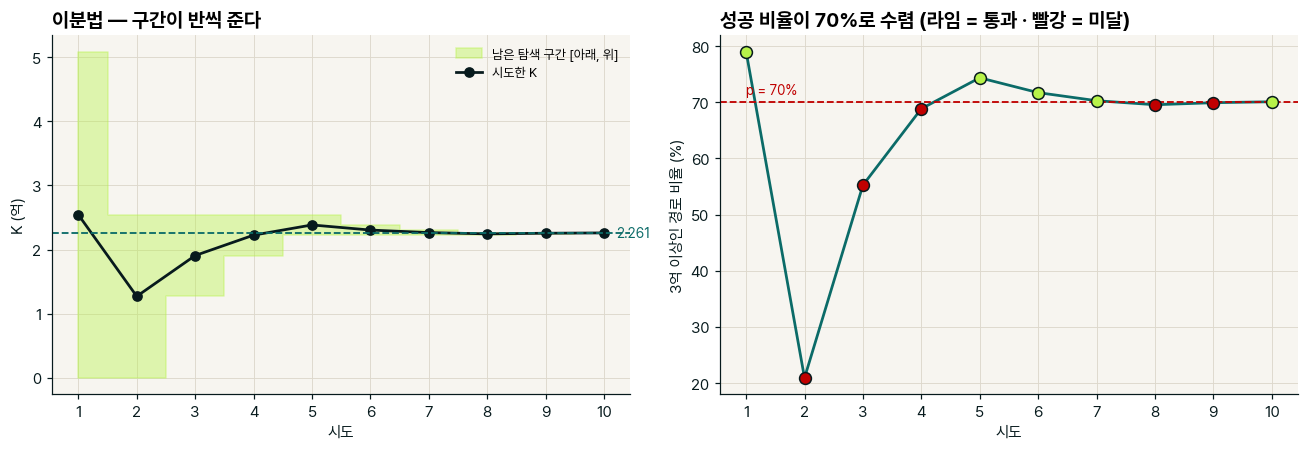

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.2))
it = [l[0] for l in log]; Kt = [l[1] for l in log]; pt = [l[2] * 100 for l in log]
ax1.fill_between(it, [l[3] for l in log], [l[4] for l in log], color=LIME, alpha=0.4, step="mid", label="남은 탐색 구간 [아래, 위]")
ax1.plot(it, Kt, color=INK, marker="o", lw=1.8, label="시도한 K")
ax1.axhline(K_M, color=TEAL, ls="--", lw=1.2); ax1.text(10.2, K_M, f"{K_M:.3f}", color=TEAL, va="center", fontsize=9)
ax1.set_xlabel("시도"); ax1.set_ylabel("K (억)"); ax1.set_xticks(it)
ax1.set_title("이분법 — 구간이 반씩 준다"); ax1.legend(fontsize=8.5)
ax2.plot(it, pt, color=TEAL, marker="o", lw=1.8)
for i, p_ in zip(it, pt):
    ax2.scatter(i, p_, s=60, color=LIME if p_ >= 70 else RED, edgecolor=INK, zorder=5)
ax2.axhline(70, color=RED, ls="--", lw=1.2); ax2.text(1, 71.5, "p = 70%", color=RED, fontsize=9)
ax2.set_xlabel("시도"); ax2.set_ylabel("3억 이상인 경로 비율 (%)"); ax2.set_xticks(it)
ax2.set_title("성공 비율이 70%로 수렴 (라임 = 통과 · 빨강 = 미달)")
fig.tight_layout(); plt.show()

**비교** — 우선순위 순서(계좌 분리) 9.14억 vs 한 계좌 격자 7.1억 · w 60%: 격자가 약 2억 싸지만 그때 Safety는 **확정이 아니라 확률 95%** 입니다(54장).
목표를 우선순위대로 하나씩 풀면 조합 대신 1차원 탐색이 목표 수만큼 — 확정할 것은 확정하고 남은 것만 확률로.

## 6. 변수 묶기 ① — Das–Markowitz는 비중 6개 대신 γ 3개 (강의 52장)
묶기 전: 계좌마다 비중 둘(채권 · 저위험)을 고른다 → 6개, 10칸씩이면 10⁶ 후보.
묶은 뒤: 효율선 위 한 점을 정하는 γ 하나씩 → 3개, 각각 1차원 방정식. g, v는 '비중 합 = 1'만 둔 평균-분산 해에서 온다.

In [11]:
from scipy.stats import norm
from scipy.optimize import brentq
MU = np.array([0.05, 0.10, 0.25]); S = np.array([[0.0025, 0, 0], [0, 0.04, 0.02], [0, 0.02, 0.25]])
Si = np.linalg.inv(S); one = np.ones(3)
A_, C_ = one @ Si @ MU, one @ Si @ one; d_ = MU @ Si @ MU - A_**2 / C_
g_ = Si @ one / C_; v_ = Si @ (MU - A_ / C_ * one)
print("Σ⁻¹1 =", np.round(Si @ one, 2), f"· C = {C_:.2f} → g = Σ⁻¹1 ÷ C =", np.round(g_, 3), "(최소분산)")
print("μ − (A/C)1 =", np.round(MU - A_ / C_, 4), "→ v =", np.round(v_, 3), "(위험을 더 지는 방향)")
GAM = {}
for a, H, al in [("은퇴", -0.10, 0.05), ("교육", -0.05, 0.15), ("상속", -0.15, 0.20)]:
    z = -norm.ppf(al)
    x = brentq(lambda t: A_ / C_ + d_ * t - z * math.sqrt(1 / C_ + d_ * t * t) - H, 1e-9, 10)
    GAM[a] = 1 / x
    print(f"{a}: γ 하나 = {1 / x:.3f} → 비중 g + v/γ = {np.round(100 * (g_ + v_ * x), 1)}%")
check("은퇴 γ", GAM["은퇴"], 3.795, 0.0005, ".3f"); check("교육 γ", GAM["교육"], 2.706, 0.0005, ".3f"); check("상속 γ", GAM["상속"], 0.877, 0.0005, ".3f")
w_ret = g_ + v_ / GAM["은퇴"]
for i, L in enumerate([53.9, 26.6, 19.5]):
    check(f"은퇴 비중 {i + 1} (%)", 100 * w_ret[i], L, 0.05, ".1f")
print(f"고를 숫자: 묶기 전 6개(후보 10⁶ = {10**6:,}) → 묶은 뒤 3개(각각 1차원)")

Σ⁻¹1 = [400.    23.96   2.08] · C = 426.04 → g = Σ⁻¹1 ÷ C = [0.939 0.056 0.005] (최소분산)
μ − (A/C)1 = [-0.0038  0.0462  0.1962] → v = [-1.516  0.795  0.721] (위험을 더 지는 방향)
은퇴: γ 하나 = 3.795 → 비중 g + v/γ = [53.9 26.6 19.5]%
교육: γ 하나 = 2.706 → 비중 g + v/γ = [37.9 35.  27.1]%
상속: γ 하나 = 0.877 → 비중 g + v/γ = [-78.9  96.2  82.7]%
✓ 은퇴 γ: 계산 3.795 · 강의 3.795 (허용 ±0.0005)
✓ 교육 γ: 계산 2.706 · 강의 2.706 (허용 ±0.0005)
✓ 상속 γ: 계산 0.877 · 강의 0.877 (허용 ±0.0005)
✓ 은퇴 비중 1 (%): 계산 53.9 · 강의 53.9 (허용 ±0.05)
✓ 은퇴 비중 2 (%): 계산 26.6 · 강의 26.6 (허용 ±0.05)
✓ 은퇴 비중 3 (%): 계산 19.5 · 강의 19.5 (허용 ±0.05)
고를 숫자: 묶기 전 6개(후보 10⁶ = 1,000,000) → 묶은 뒤 3개(각각 1차원)


## 7. 변수 묶기 ② — CPPI는 해마다의 비중 대신 승수 m 하나 (강의 53장)
묶기 전: 매년 비중을 직접 고른다(10년 × 비중 2 = 20개). 묶은 뒤: floor F는 식(필수 목표의 현재가치), 노출 E = m × (W − F)는 규칙이 계산 → 고를 것은 m 하나.
A = 100 · F = 80 · m = 3 → 1년차 E = 60 · 위험 블록 −20% → A = 88 → 2년차 E = 3 × (88 − 80) = 24.

In [12]:
A, Ff, m = 100.0, 80.0, 3.0
E1 = m * (A - Ff); A2 = (A - E1) + E1 * 0.8; E2 = m * (A2 - Ff)
print(f"1년차 E = {m:.0f} × ({A:.0f} − {Ff:.0f}) = {E1:.0f} → 위험 블록 −20% → A = {A2:.0f} → 2년차 E = {m:.0f} × ({A2:.0f} − {Ff:.0f}) = {E2:.0f}")
check("CPPI 1년차 E", E1, 60, 1e-9, ".0f"); check("−20% 뒤 A", A2, 88, 1e-9, ".0f"); check("2년차 E", E2, 24, 1e-9, ".0f")

1년차 E = 3 × (100 − 80) = 60 → 위험 블록 −20% → A = 88 → 2년차 E = 3 × (88 − 80) = 24
✓ CPPI 1년차 E: 계산 60 · 강의 60 (허용 ±1e-09)
✓ −20% 뒤 A: 계산 88 · 강의 88 (허용 ±1e-09)
✓ 2년차 E: 계산 24 · 강의 24 (허용 ±1e-09)


---
### 확인 결과 요약
이 노트북에서 강의본 숫자와 비교한 항목을 모아 봅니다. 모두 ✓이면 강의본 숫자를 그대로 재현한 것입니다.

In [13]:
# ── 확인 결과 요약 ──
n_ok = sum(ok for _, ok in CHECKS)
print(f"강의본 숫자 확인 {n_ok} / {len(CHECKS)} 통과" + (" — 빠른 모드라 일부 차이는 정상" if FAST else ""))
for label, ok in CHECKS:
    if not ok:
        print("  ✗", label)

강의본 숫자 확인 64 / 64 통과


---
## 바꿔 보기 (연습 문제)

1. 확률 기준을 (95%, 70%, 30%) → (90%, 70%, 50%)로 바꾸면(`TARGET`) 한 계좌 격자의 최소 K와 w는? 우선순위 순서의 합계는?
2. 시드를 바꿔(`SEED = 7`, 2절부터 다시) 격자 최소 K가 7.1억에서 흔들리는지 보라. 0.1억 간격의 격자에서 표본오차는 얼마나 중요한가?
3. 주식 비중 후보를 5%p → 1%p로 촘촘히(`WS = np.round(np.arange(0, 1.0001, 0.01), 2)`) 하면 최소 K가 더 내려가는가? 후보 수와 시간은?

아래 빈 셀에서 직접 해 보세요. 위 셀의 함수를 그대로 불러 쓰면 됩니다.

In [14]:
# 여기에 직접 해 보기

In [15]:
# 여기에 직접 해 보기

In [16]:
# 여기에 직접 해 보기